# Customer Review Intelligence System
## Notebook 01 — Exploratory Data Analysis

**Dataset:** Yelp Review Full (`yelp_review_full` via HuggingFace Datasets)  
**Label mapping:** 1–2 stars → Negative · 3 stars → Neutral · 4–5 stars → Positive  
**Goal:** Understand the data before training. Every chart here has a business interpretation and informs a downstream decision.

**Run environment:** Local laptop (CPU). No GPU required.

---

## 0. Install and import

In [4]:
# Run once if not already installed
!pip install datasets transformers matplotlib seaborn pandas wordcloud tqdm

  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.1 kB ? eta -:--:--


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [1]:
import datasets
print(datasets.__version__)

5.0.0


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re

from datasets import load_dataset
from transformers import AutoTokenizer

# Optional — comment out if wordcloud is not installed
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("wordcloud not installed — word cloud cells will be skipped.")

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# Colour palette used consistently across all charts
CLASS_COLORS = {
    'Positive': '#2ecc71',
    'Neutral':  '#3498db',
    'Negative': '#e74c3c',
}

print('Imports OK')

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Imports OK


---
## 1. Load dataset

We load the full Yelp Review Full dataset from HuggingFace.  
First run will download ~700 MB and cache locally — subsequent runs are instant.

In [4]:
print('Loading Yelp Review Full from HuggingFace...')
dataset = load_dataset('Yelp/yelp_review_full')
print(dataset)

Loading Yelp Review Full from HuggingFace...


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})


In [5]:
# Convert to pandas for EDA — training split only
df_raw = dataset['train'].to_pandas()

# Yelp labels are 0-indexed (0=1 star, 4=5 stars) — shift to 1–5 for clarity
df_raw['stars'] = df_raw['label'] + 1

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
print(f'\nNull values:\n{df_raw.isnull().sum()}')
print(f'\nStar distribution (raw):\n{df_raw["stars"].value_counts().sort_index()}')

Shape: (650000, 3)
Columns: ['label', 'text', 'stars']

Null values:
label    0
text     0
stars    0
dtype: int64

Star distribution (raw):
stars
1    130000
2    130000
3    130000
4    130000
5    130000
Name: count, dtype: int64


In [6]:
# Apply 3-class label mapping
def map_label(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

df_raw['sentiment'] = df_raw['stars'].apply(map_label)

print('Label mapping applied.')
print(df_raw['sentiment'].value_counts())

Label mapping applied.
sentiment
Positive    260000
Negative    260000
Neutral     130000
Name: count, dtype: int64


---
## 2. Class distribution

**Why this matters:** Natural Yelp distribution is heavily skewed toward positive reviews.  
Training on this imbalance would bias the model toward Positive predictions.  
These charts justify the decision to sample 40K per class (120K balanced total).

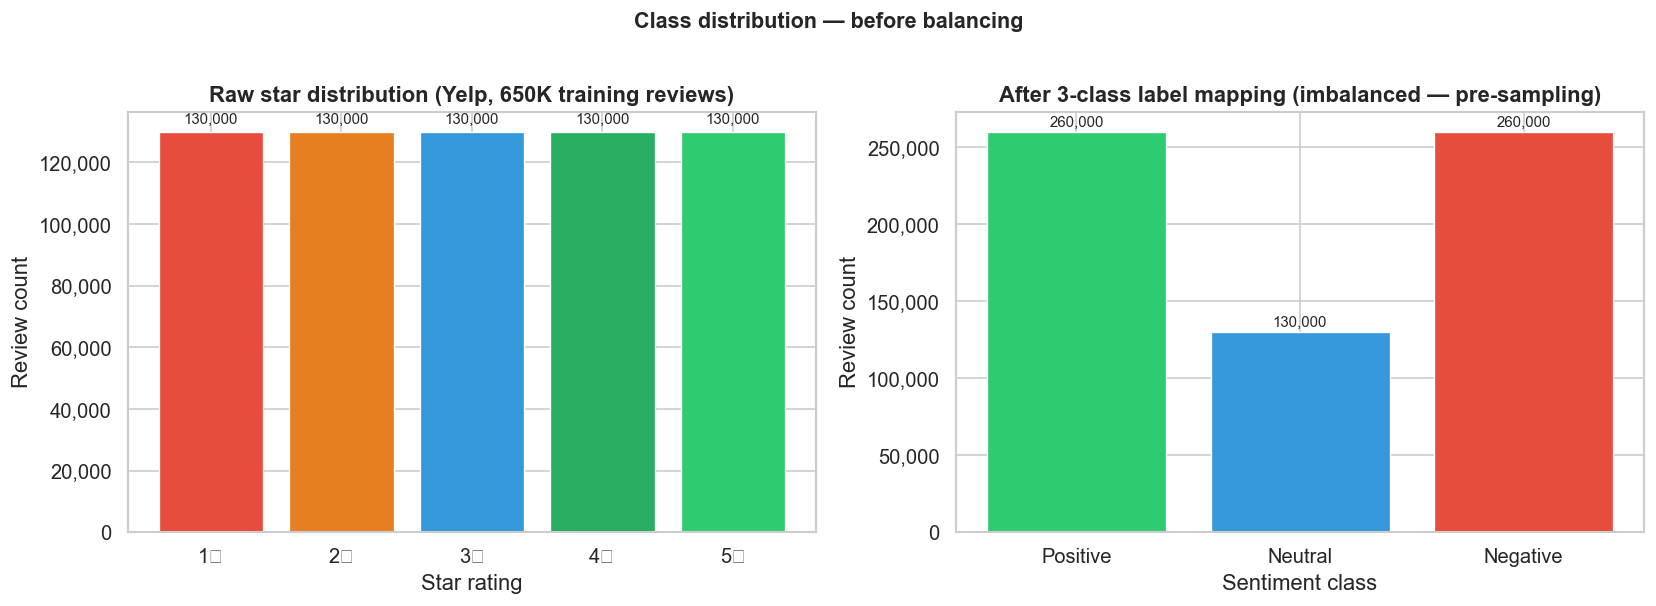

Observation: Positive class dominates. Sampling 40K per class is required before training.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw star distribution
star_counts = df_raw['stars'].value_counts().sort_index()
axes[0].bar(
    [str(s) + '★' for s in star_counts.index],
    star_counts.values,
    color=['#e74c3c', '#e67e22', '#3498db', '#27ae60', '#2ecc71'],
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Raw star distribution (Yelp, 650K training reviews)', fontweight='bold')
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Review count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

# Right: after label mapping
label_counts = df_raw['sentiment'].value_counts()
ordered = ['Positive', 'Neutral', 'Negative']
counts = [label_counts[l] for l in ordered]
bars = axes[1].bar(
    ordered, counts,
    color=[CLASS_COLORS[l] for l in ordered],
    edgecolor='white', linewidth=0.8
)
axes[1].set_title('After 3-class label mapping (imbalanced — pre-sampling)', fontweight='bold')
axes[1].set_xlabel('Sentiment class')
axes[1].set_ylabel('Review count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

plt.suptitle('Class distribution — before balancing', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('C:\customer-review-intelligence\data\eda_balanced_distribution.png')
plt.show()
print('Observation: Positive class dominates. Sampling 40K per class is required before training.')

---
## 3. Sample balanced dataset

40K per class → 120K total. This is the dataset that goes into training.

In [18]:
import os
print(os.getcwd())

c:\customer-review-intelligence\notebooks


In [22]:
print(df_raw["sentiment"].value_counts())

sentiment
Positive    260000
Negative    260000
Neutral     130000
Name: count, dtype: int64


In [23]:
df_raw.groupby("sentiment").size()

sentiment
Negative    260000
Neutral     130000
Positive    260000
dtype: int64

In [24]:
df = (
    df_raw
    .groupby("sentiment", group_keys=False)
    .apply(lambda x: x.sample(40000, random_state=42))
)

In [25]:
import pandas as pd
print(pd.__version__)

3.0.3


In [26]:
df_raw.groupby("sentiment").size()

sentiment
Negative    260000
Neutral     130000
Positive    260000
dtype: int64

In [30]:
SAMPLE_PER_CLASS = 40_000
RANDOM_STATE = 42

SAMPLE_PER_CLASS = 40_000
RANDOM_STATE = 42

df = (
    df_raw.groupby("sentiment", group_keys=False)
    .sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Balanced dataset shape: {df.shape}")
print(df["sentiment"].value_counts())
print(f'Class distribution after sampling:\n{df["sentiment"].value_counts()}')

# Verify balance
assert df['sentiment'].value_counts().std() == 0, 'Classes are not balanced!'
print('\nBalance check passed.')

Balanced dataset shape: (120000, 4)
sentiment
Negative    40000
Neutral     40000
Positive    40000
Name: count, dtype: int64
Class distribution after sampling:
sentiment
Negative    40000
Neutral     40000
Positive    40000
Name: count, dtype: int64

Balance check passed.


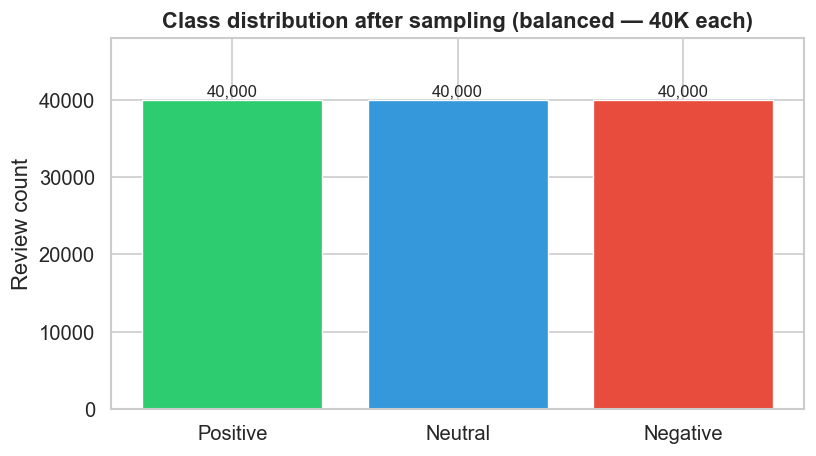

In [31]:
# Confirm balanced distribution visually
fig, ax = plt.subplots(figsize=(7, 4))
ordered = ['Positive', 'Neutral', 'Negative']
ax.bar(
    ordered,
    [SAMPLE_PER_CLASS] * 3,
    color=[CLASS_COLORS[l] for l in ordered],
    edgecolor='white', linewidth=0.8
)
ax.set_title('Class distribution after sampling (balanced — 40K each)', fontweight='bold')
ax.set_ylabel('Review count')
ax.set_ylim(0, 48000)
for i, label in enumerate(ordered):
    ax.text(i, SAMPLE_PER_CLASS + 400, f'{SAMPLE_PER_CLASS:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/eda_balanced_distribution.png', bbox_inches='tight')
plt.show()

---
## 4. Review length distribution

**Why this matters:**
- Informs the `max_length` parameter for the DistilBERT tokenizer  
- Negative reviews tend to be longer (people explain complaints in detail)  
- Token length > 512 gets truncated — we need to know how much data is lost

In [32]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print('Character count stats by class:')
print(df.groupby('sentiment')['char_count'].describe()[['mean','50%','75%','max']].round(0))
print('\nWord count stats by class:')
print(df.groupby('sentiment')['word_count'].describe()[['mean','50%','75%','max']].round(0))

Character count stats by class:
            mean    50%     75%     max
sentiment                              
Negative   822.0  607.0  1070.0  5112.0
Neutral    760.0  583.0  1004.0  5042.0
Positive   634.0  460.0   831.0  5070.0

Word count stats by class:
            mean    50%    75%     max
sentiment                             
Negative   152.0  113.0  198.0  1025.0
Neutral    139.0  107.0  183.0   973.0
Positive   115.0   84.0  151.0   956.0


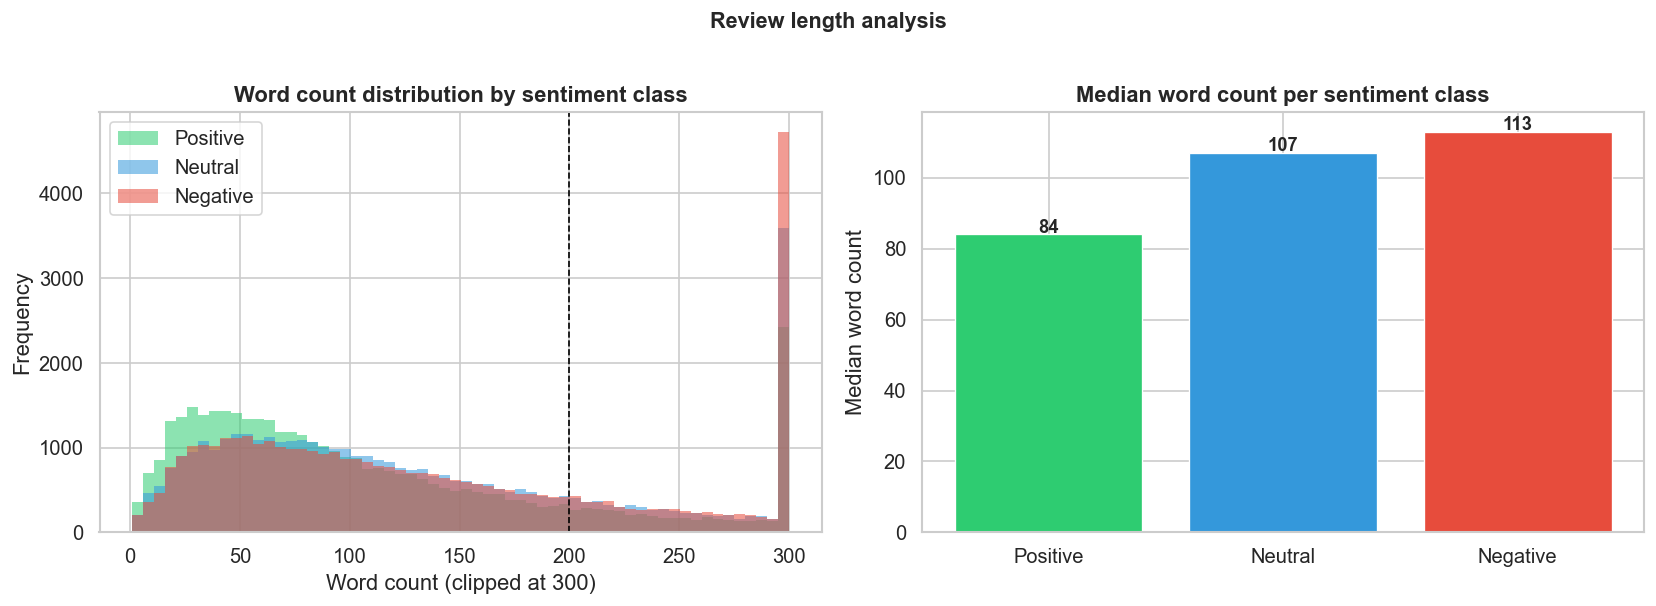

Observation: Negative reviews are consistently longer — people explain complaints in more detail.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distributions
for label in ['Positive', 'Neutral', 'Negative']:
    subset = df[df['sentiment'] == label]['word_count']
    subset_clipped = subset.clip(upper=300)  # clip extreme outliers for readability
    axes[0].hist(
        subset_clipped, bins=60, alpha=0.55,
        color=CLASS_COLORS[label], label=label, edgecolor='none'
    )

axes[0].set_title('Word count distribution by sentiment class', fontweight='bold')
axes[0].set_xlabel('Word count (clipped at 300)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].axvline(x=200, color='black', linestyle='--', linewidth=1, label='~max_length=256 tokens')

# Median word count per class — simple bar
medians = df.groupby('sentiment')['word_count'].median().reindex(['Positive', 'Neutral', 'Negative'])
axes[1].bar(
    medians.index, medians.values,
    color=[CLASS_COLORS[l] for l in medians.index],
    edgecolor='white', linewidth=0.8
)
axes[1].set_title('Median word count per sentiment class', fontweight='bold')
axes[1].set_ylabel('Median word count')
for i, (label, val) in enumerate(medians.items()):
    axes[1].text(i, val + 0.5, f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Review length analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_length_distribution.png', bbox_inches='tight')
plt.show()
print('Observation: Negative reviews are consistently longer — people explain complaints in more detail.')

---
## 5. Example reviews per class

**Why this matters:**  
Manual inspection of 3-star (Neutral) reviews is the key sanity check.  
Do they genuinely read as mixed/neutral, or are they clearly positive/negative?  
This is the evidence for the label mapping design decision.

In [34]:
pd.set_option('display.max_colwidth', 300)

N_EXAMPLES = 5

for label in ['Positive', 'Neutral', 'Negative']:
    print(f'\n{"="*70}')
    print(f'  CLASS: {label.upper()}')
    print(f'{"="*70}')
    samples = df[df['sentiment'] == label]['text'].sample(N_EXAMPLES, random_state=42).tolist()
    for i, text in enumerate(samples, 1):
        # Truncate very long reviews for display
        display_text = text[:400] + '...' if len(text) > 400 else text
        print(f'\n[{i}] {display_text}')


  CLASS: POSITIVE

[1] I stayed at this hotel from Dec 13-15, 2013, and I would definitely recommend it.  I'm a platinum member and used my points for my stay.  The staff was very welcoming upon check in.  They have a happy hour which includes nachos! And they also offer cookies at certain hours in the evening.  Our room was very spacious.  The hotel is not far from Scottsdale Fashion Square Mall.  Definitely the nicest...

[2] We have seen Dr. Hansen three times now.  We are new pet owners and got a boxer puppy. She is always super friendly and loving towards Lily, our little boxer.  She's professional yet personable too. She answers any and everything question we have without making us feel dumb for asking whatever it may be. Dr. Hansen explains everything in a way to where we can understand as well, I hate when doctor...

[3] We aren't big buffet fans overall, but they are a very interesting venue, at least here in Las Vegas.  You have a wide range of quality in the buffets, not ju

In [35]:
# Focused check: do 3-star reviews read as neutral?
print('NEUTRAL CLASS INSPECTION — 3-star reviews:')
print('Look for: mixed opinions, hedged language, neither clearly positive nor negative.\n')

neutral_samples = df[df['sentiment'] == 'Neutral']['text'].sample(10, random_state=99).tolist()
for i, text in enumerate(neutral_samples, 1):
    display_text = text[:300] + '...' if len(text) > 300 else text
    print(f'[{i}] {display_text}\n')

NEUTRAL CLASS INSPECTION — 3-star reviews:
Look for: mixed opinions, hedged language, neither clearly positive nor negative.

[1] I love this place and always order off the buffet. I have never had a complaint about it and frequent Tsom. However, I went with a friend, she ordered a wrap and it was a veg burger, cut in half, with a leaf of lettuce and a few diced tomatoes. Not even a sauce was added.

[2] I've been eating here since the 90's and it's been my go-to Filipino food place because the food is good and the portions are generous, but it looks like they recently raised their prices and switched their containers to smaller ones, so you don't get as much. The food is still good, but the portion...

[3] = =  TUESDAY THRU THURSDAY LUNCH BUFFET!   = =\n\nOk, Yelp won't steer me wrong.  Is this place good?\n\nNo, it's 1 Star!  Worst restaurant in the world!     :-((\nNo, it's 5 Stars!  Best Buffet in the world!  Beats Bacchanal in Vegas!     :-))\nNo, it's 1 Star!  Worst food in the w

---
## 6. Word frequency analysis

Top words per class after stopword removal.  
**What to look for:** Do class-distinguishing words make intuitive sense?  
If 'amazing' appears in Negative or 'terrible' in Positive, there may be label noise.

In [36]:
STOPWORDS = {
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'the', 'a', 'an', 'and',
    'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'is', 'was',
    'are', 'were', 'it', 'this', 'that', 'they', 'their', 'there', 'be',
    'been', 'have', 'has', 'had', 'do', 'did', 'not', 'so', 'if', 'as',
    'from', 'by', 'up', 'about', 'out', 'would', 'which', 'he', 'she',
    'his', 'her', 'its', 'into', 'then', 'than', 'just', 'also', 'will',
    'can', 'get', 'got', 'all', 'one', 'more', 'when', 'how', 'what',
    'very', 'no', 'back', 'even', 'time', 'really', 'here', 'us', 'them'
}

def get_top_words(texts, n=25, stopwords=STOPWORDS):
    """Return top-n words from a list of texts, excluding stopwords."""
    words = []
    for text in texts:
        tokens = re.findall(r"[a-z']+", text.lower())
        words.extend([t for t in tokens if t not in stopwords and len(t) > 2])
    return Counter(words).most_common(n)

top_words = {}
for label in ['Positive', 'Neutral', 'Negative']:
    texts = df[df['sentiment'] == label]['text'].tolist()
    top_words[label] = get_top_words(texts)

print('Top words computed.')

Top words computed.


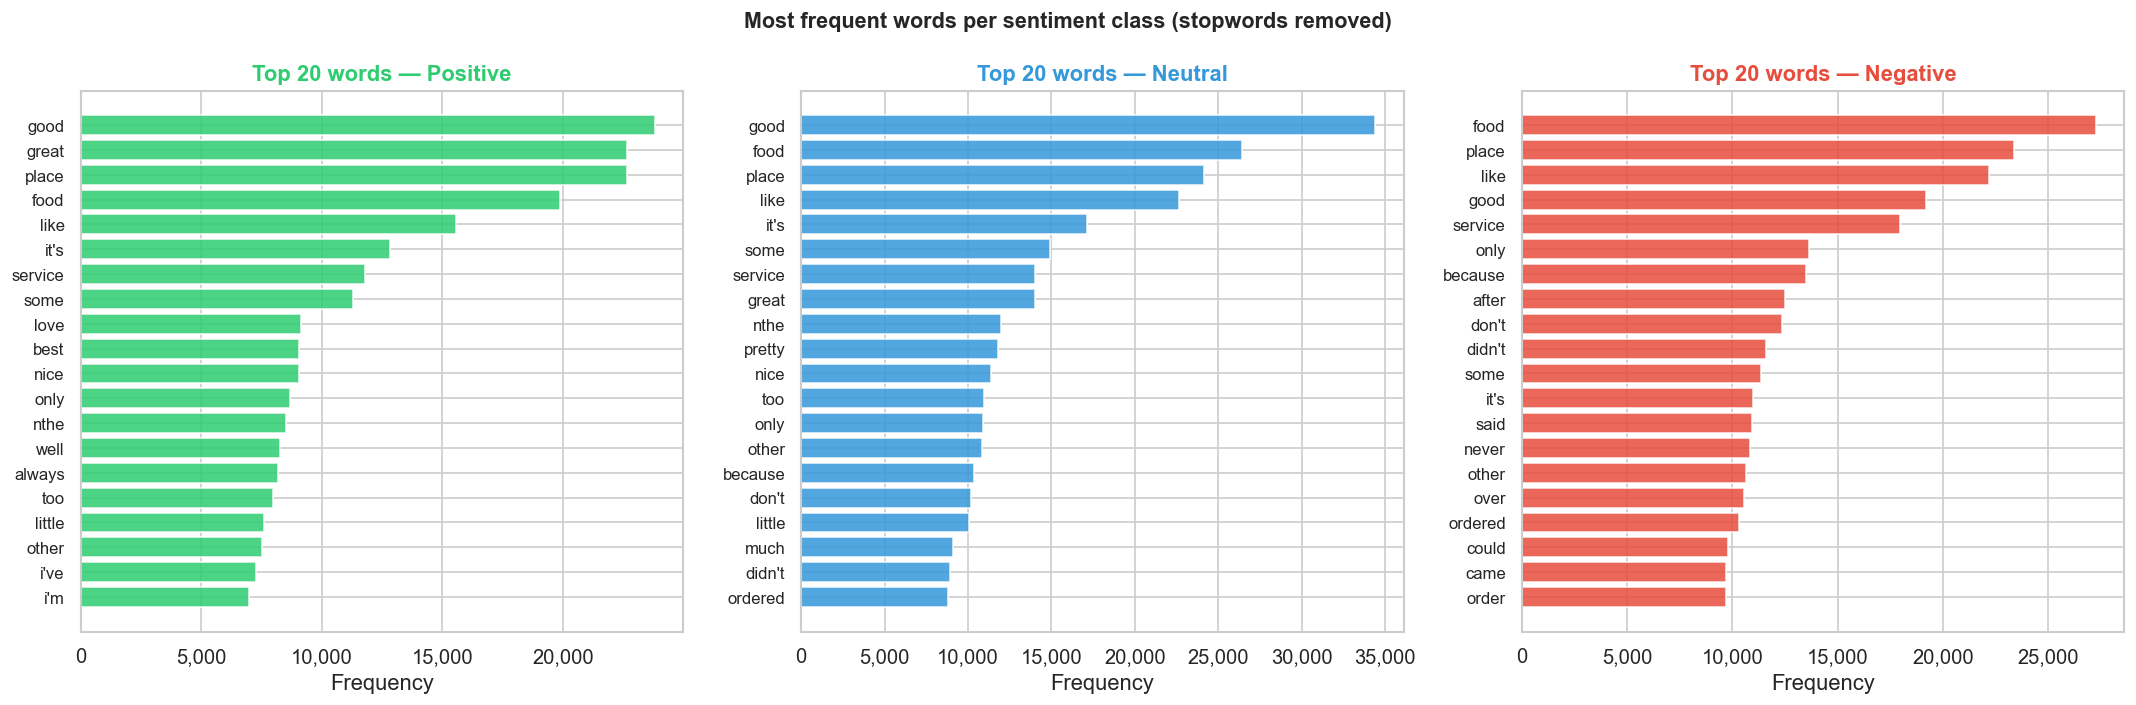

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label in zip(axes, ['Positive', 'Neutral', 'Negative']):
    words, counts = zip(*top_words[label][:20])
    y_pos = range(len(words))
    ax.barh(
        y_pos, counts,
        color=CLASS_COLORS[label], alpha=0.85, edgecolor='white'
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'Top 20 words — {label}', fontweight='bold', color=CLASS_COLORS[label])
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Most frequent words per sentiment class (stopwords removed)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_top_words.png', bbox_inches='tight')
plt.show()

---
## 7. Word clouds


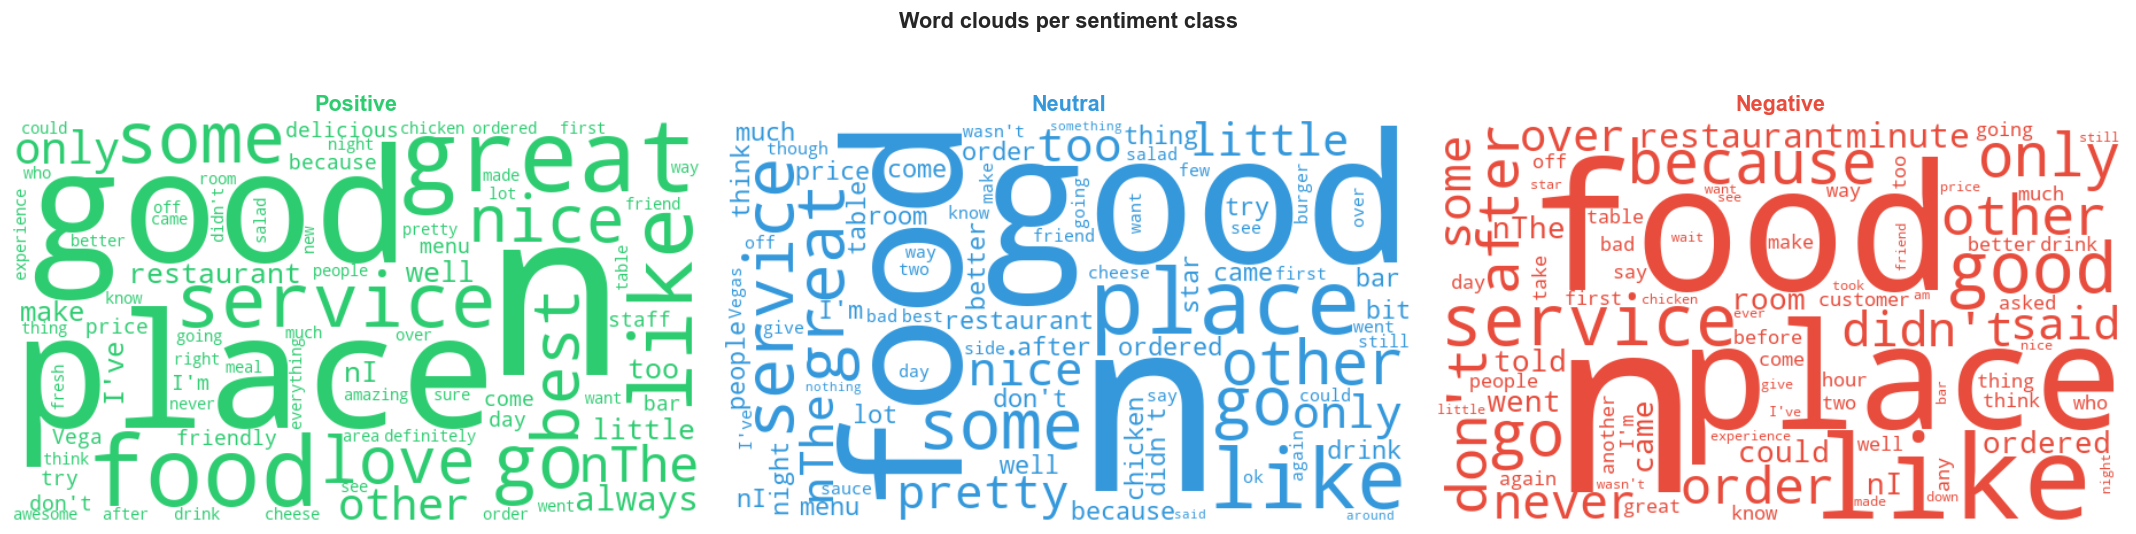

In [38]:
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, label in zip(axes, ['Positive', 'Neutral', 'Negative']):
        text_blob = ' '.join(
            df[df['sentiment'] == label]['text']
            .sample(5000, random_state=42)
            .tolist()
        )
        wc = WordCloud(
            width=600, height=350,
            background_color='white',
            color_func=lambda *args, **kwargs: CLASS_COLORS[label],
            stopwords=STOPWORDS,
            max_words=80,
            collocations=False
        ).generate(text_blob)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{label}', fontweight='bold', fontsize=13, color=CLASS_COLORS[label])

    plt.suptitle('Word clouds per sentiment class', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/eda_wordclouds.png', bbox_inches='tight')
    plt.show()
else:
    print('Skipped — wordcloud not installed. Run: pip install wordcloud')

---
## 8. Tokenizer analysis

**Why this matters:**  
DistilBERT has a hard 512-token limit. Reviews longer than this get **silently truncated**.  
This analysis determines the optimal `max_length` for training — the sweet spot between  
capturing full review content and keeping memory/speed reasonable.

**Decision rule:** Use the token length that covers ≥ 97% of all reviews.

In [39]:
print('Loading DistilBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Sample 3K reviews for speed (representative enough)
TOKENIZER_SAMPLE = 3000
sample_texts = df['text'].sample(TOKENIZER_SAMPLE, random_state=42).tolist()

print(f'Tokenizing {TOKENIZER_SAMPLE} sampled reviews...')
token_lengths = [
    len(tokenizer.encode(text, truncation=False, add_special_tokens=True))
    for text in sample_texts
]

token_lengths = np.array(token_lengths)
print(f'\nToken length stats across {TOKENIZER_SAMPLE} sampled reviews:')
for pct in [50, 75, 90, 95, 97, 99, 100]:
    print(f'  p{pct:3d}: {np.percentile(token_lengths, pct):.0f} tokens')

Loading DistilBERT tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (654 > 512). Running this sequence through the model will result in indexing errors


Tokenizing 3000 sampled reviews...

Token length stats across 3000 sampled reviews:
  p 50: 139 tokens
  p 75: 248 tokens
  p 90: 388 tokens
  p 95: 498 tokens
  p 97: 589 tokens
  p 99: 808 tokens
  p100: 1342 tokens


97% coverage is not reached within DistilBERT's 512-token limit.


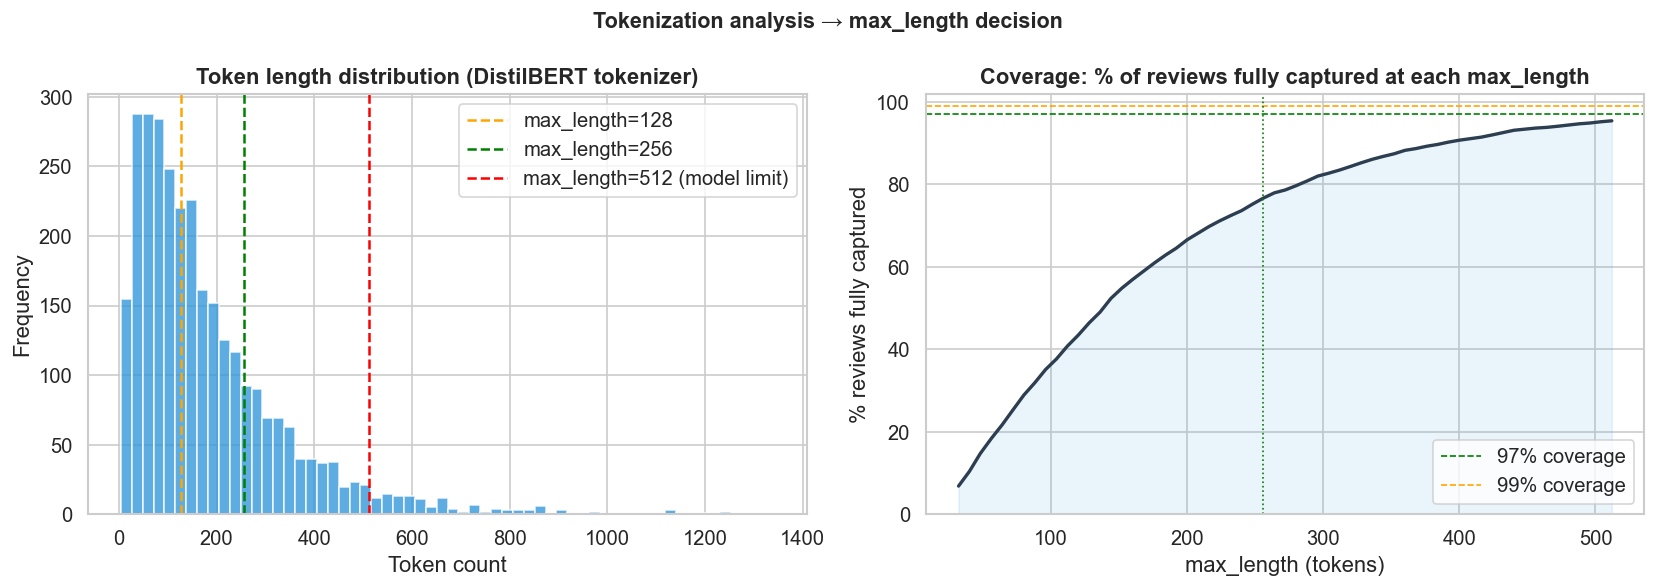


Reviews > 256 tokens (truncated at max_length=256): 23.3%
Reviews > 512 tokens (exceed model hard limit):      4.6%

Decision: Use max_length=256 in train.ipynb.
This captures ~77% of reviews without waste.


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(token_lengths, bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=128, color='orange', linestyle='--', linewidth=1.5, label='max_length=128')
axes[0].axvline(x=256, color='green',  linestyle='--', linewidth=1.5, label='max_length=256')
axes[0].axvline(x=512, color='red',    linestyle='--', linewidth=1.5, label='max_length=512 (model limit)')
axes[0].set_title('Token length distribution (DistilBERT tokenizer)', fontweight='bold')
axes[0].set_xlabel('Token count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Coverage curve — what % of reviews are fully captured at each max_length
lengths_to_check = range(32, 513, 8)
coverage = [np.mean(token_lengths <= l) * 100 for l in lengths_to_check]
axes[1].plot(list(lengths_to_check), coverage, color='#2c3e50', linewidth=2)
axes[1].axhline(y=97, color='green', linestyle='--', linewidth=1, label='97% coverage')
axes[1].axhline(y=99, color='orange', linestyle='--', linewidth=1, label='99% coverage')
axes[1].axvline(x=256, color='green', linestyle=':', linewidth=1)
axes[1].fill_between(list(lengths_to_check), coverage, alpha=0.1, color='#3498db')
axes[1].set_title('Coverage: % of reviews fully captured at each max_length', fontweight='bold')
axes[1].set_xlabel('max_length (tokens)')
axes[1].set_ylabel('% reviews fully captured')
axes[1].legend()
axes[1].set_ylim(0, 102)

# Annotate the 97% crossing point
if max(coverage) >= 97:
    idx_97 = next(i for i, c in enumerate(coverage) if c >= 97)
    crossing_length = list(lengths_to_check)[idx_97]

    axes[1].annotate(
        f'97% coverage\nat {crossing_length} tokens',
        xy=(crossing_length, 97),
        xytext=(crossing_length + 40, 88),
        arrowprops=dict(arrowstyle='->', color='green'),
        fontsize=9,
        color='green'
    )
else:
    print("97% coverage is not reached within DistilBERT's 512-token limit.")


plt.suptitle('Tokenization analysis → max_length decision', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_token_lengths.png', bbox_inches='tight')
plt.show()

pct_over_256 = np.mean(token_lengths > 256) * 100
pct_over_512 = np.mean(token_lengths > 512) * 100
print(f'\nReviews > 256 tokens (truncated at max_length=256): {pct_over_256:.1f}%')
print(f'Reviews > 512 tokens (exceed model hard limit):      {pct_over_512:.1f}%')
print(f'\nDecision: Use max_length=256 in train.ipynb.')
print(f'This captures ~{100-pct_over_256:.0f}% of reviews without waste.')

---
## 9. Save processed dataset

Export the balanced, label-mapped 120K dataset to CSV.  
This is what `02_train.ipynb` loads on Kaggle — no re-downloading needed.

In [44]:
from sklearn.model_selection import train_test_split

LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label_id'] = df['sentiment'].map(LABEL2ID)

# 80 / 10 / 10 split — stratified to preserve class balance
df_train, df_temp = train_test_split(
    df[['text', 'sentiment', 'label_id']],
    test_size=0.20,
    stratify=df['sentiment'],
    random_state=42
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp['sentiment'],
    random_state=42
)

df_train.to_csv('../data/train.csv', index=False)
df_val.to_csv('../data/val.csv',   index=False)
df_test.to_csv('../data/test.csv',  index=False)

print(f'Train:      {len(df_train):>7,} rows')
print(f'Validation: {len(df_val):>7,} rows')
print(f'Test:       {len(df_test):>7,} rows')
print(f'\nSaved to data/ directory.')
print(f'Upload data/ folder to Kaggle before running 02_train.ipynb.')

Train:       96,000 rows
Validation:  12,000 rows
Test:        12,000 rows

Saved to data/ directory.
Upload data/ folder to Kaggle before running 02_train.ipynb.


---
## 10. EDA summary

Key findings that inform downstream decisions:

In [45]:
neg_median = df[df['sentiment']=='Negative']['word_count'].median()
pos_median = df[df['sentiment']=='Positive']['word_count'].median()
neu_median = df[df['sentiment']=='Neutral']['word_count'].median()

print('=' * 60)
print('  EDA SUMMARY')
print('=' * 60)
print(f'''
Dataset
  Source         : Yelp Review Full (HuggingFace)
  Original size  : {len(df_raw):,} training reviews
  After sampling : {len(df):,} reviews (40K per class)
  Train/Val/Test : {len(df_train):,} / {len(df_val):,} / {len(df_test):,}

Label mapping
  1–2 stars → Negative  ({df[df["sentiment"]=="Negative"].shape[0]:,} reviews)
  3   stars → Neutral   ({df[df["sentiment"]=="Neutral"].shape[0]:,} reviews)
  4–5 stars → Positive  ({df[df["sentiment"]=="Positive"].shape[0]:,} reviews)

Review length (word count medians)
  Positive : {pos_median:.0f} words
  Neutral  : {neu_median:.0f} words
  Negative : {neg_median:.0f} words  ← longest (people explain complaints)

Tokenization decision
  max_length = 256 tokens
  Captures  ~{100-pct_over_256:.0f}% of reviews without truncation
  {pct_over_256:.1f}% of reviews will be truncated
  {pct_over_512:.1f}% exceed the model's hard 512-token limit

Label quality note
  Neutral labels are a 3-star proxy, not human-annotated.
  3-star reviews are genuinely mixed — expect lower F1 on neutral
  class (~58–65%) vs positive/negative (~75–80%).
  This is a known characteristic of proxy-labeled data, not a bug.
''')
print('=' * 60)
print('Next step: Upload data/ to Kaggle and run 02_train.ipynb')
print('=' * 60)

  EDA SUMMARY

Dataset
  Source         : Yelp Review Full (HuggingFace)
  Original size  : 650,000 training reviews
  After sampling : 120,000 reviews (40K per class)
  Train/Val/Test : 96,000 / 12,000 / 12,000

Label mapping
  1–2 stars → Negative  (40,000 reviews)
  3   stars → Neutral   (40,000 reviews)
  4–5 stars → Positive  (40,000 reviews)

Review length (word count medians)
  Positive : 84 words
  Neutral  : 107 words
  Negative : 113 words  ← longest (people explain complaints)

Tokenization decision
  max_length = 256 tokens
  Captures  ~77% of reviews without truncation
  23.3% of reviews will be truncated
  4.6% exceed the model's hard 512-token limit

Label quality note
  Neutral labels are a 3-star proxy, not human-annotated.
  3-star reviews are genuinely mixed — expect lower F1 on neutral
  class (~58–65%) vs positive/negative (~75–80%).
  This is a known characteristic of proxy-labeled data, not a bug.

Next step: Upload data/ to Kaggle and run 02_train.ipynb
